In [1]:
import torch
import torch.distributions as dist
import torch.nn.functional as F
import numpy               as np
import matplotlib.pyplot   as plt

from   scipy               import stats
from   torch               import nn
from   torchvision         import datasets, transforms

# Variational Inference with Normalizing Flows

In [2]:
# Target distribution
def pY(z):
    z1, z2 = z[..., 0], z[..., 1]
    norm   = (z1**2 + z2**2)**0.5
    exp1   = torch.exp(-0.2 * ((z1 - 2) / 0.8) ** 2)
    exp2   = torch.exp(-0.2 * ((z1 + 2) / 0.8) ** 2)
    u      = 0.5 * ((norm - 4) / 0.4) ** 2 - torch.log(exp1 + exp2)
    return torch.exp(-u)

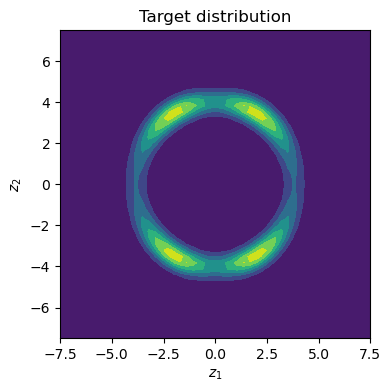

In [ ]:
# plot density pY
y1         = np.linspace(-7.5, 7.5)
y2         = np.linspace(-7.5, 7.5)
y1_s, y2_s = np.meshgrid(y1, y2)
y          = np.concatenate([y1_s[..., None], y2_s[..., None]], axis=-1)
y          = torch.tensor(y, dtype=torch.float)

plt.figure(figsize=(4, 4))
plt.title("Target distribution")
plt.xlabel('$z_1$')
plt.ylabel('$z_2$')
plt.contourf(y1_s, y2_s, pY(y))
plt.show()

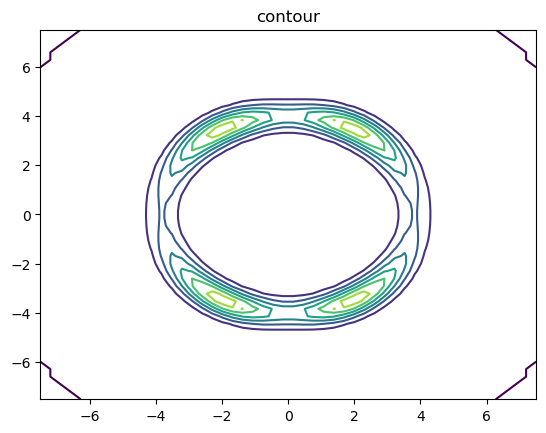

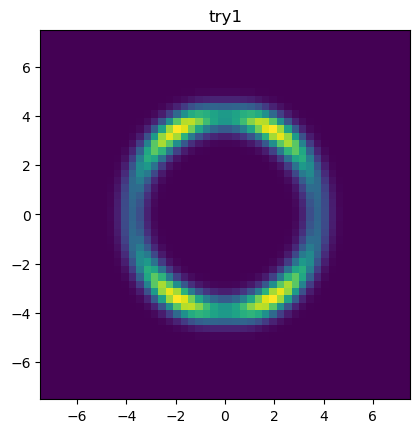

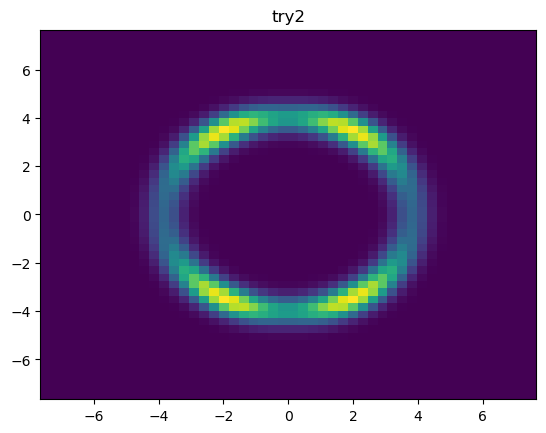

In [20]:
plt.figure()
plt.contour(y1_s, y2_s, pY(y))
plt.title('contour')
plt.show()

plt.figure()
plt.imshow(pY(y), extent = [-7.5, 7.5, -7.5, 7.5], origin = 'lower')
plt.title('try1')
plt.show()

plt.figure()
plt.pcolormesh(y1_s, y2_s, pY(y), shading='auto')
plt.title('try2')
plt.show()

In [ ]:
# Planar flows: Tz = z .+ h(w'z+b) *u    z,u,w in R^k,  b in R
class Planar(nn.Module):

    ## parameters u,w,b of the transformation
    def __init__(self, size=1, init_sigma=0.01):
        super().__init__()
        self.u = nn.Parameter(torch.randn(1, size).normal_(0, init_sigma))  # initilize u in R^k, k=size
        self.w = nn.Parameter(torch.randn(1, size).normal_(0, init_sigma))  # initilize w in R^k, k=size
        self.b = nn.Parameter(torch.zeros(1))                               # initilize b in R

    @property
    def normalized_u(self):
        """
        Needed for invertibility condition. See Appendix A.1: Rezende et al. VI with Normalizing Flows https://arxiv.org/pdf/1505.05770.pdf
        """
        # softplus
        def m(x):
            return -1 + torch.log(1 + torch.exp(x))

        wtu      = torch.matmul(self.w, self.u.t())
        w_div_w2 = self.w / torch.norm(self.w)
        return self.u + (m(wtu) - wtu) * w_div_w2

    # ============================================================    
    def psi(self, z):
        """
        ψ(z) =h′(w^tz+b)w  See eq(11): Rezende et al. VI with Normalizing Flows https://arxiv.org/pdf/1505.05770.pdf
        """
        return self.h_prime(z @ self.w.t() + self.b) @ self.w

    # define h in  Tz = z .+ h(w'z+b) *u ========================= 
    def h(self, x):
        return torch.tanh(x)

    # define h' in  Tz = z .+ h(w'z+b) *u ======================== 
    def h_prime(self, z):
        return 1 - torch.tanh(z) ** 2

    # define Tz = z .+ h(w'z+b) *u =============================== 
    def forward(self, z):
        if isinstance(z, tuple):
            z, accumulating_ldj = z
        else:
            z, accumulating_ldj = z, 0
            
        psi = self.psi(z)
        u   = self.normalized_u        
        det = (1 + psi @ u.t())                   # determinant of jacobian
        ldJ = torch.log(torch.abs(det) + 1e-6)    # log |det J_T|
        wzb = z @ self.w.t() + self.b
        Tz  = z + (u * self.h(wzb))

        return Tz, ldJ + accumulating_ldj         # transformation 

In [6]:
# define T = T_K * ... * T_2 * T_1
class Flow(nn.Module):
    def __init__(self, dim=2, n_flows=10):
        super().__init__()
        self.flow    = nn.Sequential(*[Planar(dim) for _ in range(n_flows) ])
        self.mu      = nn.Parameter(torch.randn(dim, ).normal_(0, 0.01))
        self.log_var = nn.Parameter(torch.randn(dim, ).normal_(1, 0.01))

    def forward(self, shape):
        std     = torch.exp(0.5 * self.log_var)
        eps     = torch.randn(shape)              # unit gaussian
        z0      = self.mu + eps * std             # base-dist is  z0 = mu + std * eps  eps ~ N(0,1) & var=std^2 
        zk, ldj = self.flow(z0)                   # apply transform T to z0
        return z0, zk, ldj, self.mu, self.log_var # return 1) base-dist z0, 2) transf zk=T(z0) 3) (mu, log_var)  

In [7]:
# negative ELBO = E_Q0 [ log Q0(Z_0) -sum_k log|T_k|  -log pi_Y(T(Z0)) ] where pi_Y is the target distribution
def det_loss(mu, log_var, z_0, z_k, ldj, beta):

    m       = z_0.size(0)                                               # batch size of z_0 
    log_qz0 = dist.Normal(mu, torch.exp(0.5 * log_var)).log_prob(z_0)   # log Q0(z0)   = log N(z0 | mu, var)
    log_qzk = log_qz0.sum() - ldj.sum()                                 # log Q(zk)    = log Q0(z0) + sum(log det jac)
    nll     = -torch.log(pY(z_k) + 1e-7).sum() * beta                   # log pi_Y(zk) = log P(x|z)

    return (log_qzk+nll)/m                                              #  1/m sum_j { log Q0(z0_j) - sum_k log|T_k|   - log pi_Y(zk_j) } 

In [8]:
# optimization  min KL(Q_NF || pi_Y)
def train_flow(flow, shape, epochs=1000):
    
    optim = torch.optim.Adam(flow.parameters(), lr=1e-2)

    for i in range(epochs):
        z0, zk, ldj, mu, log_var = flow(shape=shape)
        loss                     = det_loss(mu=mu, log_var=log_var, z_0=z0, z_k=zk, ldj=ldj, beta=1)
        loss.backward()
        optim.step()
        optim.zero_grad()

In [9]:
def show_samples(s0, sk, mu, title):
    
    alpha  = 0.2
    mask_1 = (z0.data[:, 0] > mu[0]) & (z0.data[:, 1] > mu[1])
    mask_2 = (z0.data[:, 0] > mu[0]) & (z0.data[:, 1] < mu[1])
    mask_3 = (z0.data[:, 0] < mu[0]) & (z0.data[:, 1] > mu[1])
    mask_4 = (z0.data[:, 0] < mu[0]) & (z0.data[:, 1] < mu[1])
    
   
   
    plt.figure(figsize=(12, 4))
    # base distribution
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, position 1
    plt.title('Base distribution $z_0$')
    plt.scatter(z0.data[:, 0][mask_1], z0.data[:, 1][mask_1], color='C0', alpha=alpha)
    plt.scatter(z0.data[:, 0][mask_2], z0.data[:, 1][mask_2], color='C1', alpha=alpha)
    plt.scatter(z0.data[:, 0][mask_3], z0.data[:, 1][mask_3], color='C3', alpha=alpha)
    plt.scatter(z0.data[:, 0][mask_4], z0.data[:, 1][mask_4], color='C4', alpha=alpha)
    plt.xlim(-7.5, 7.5)
    plt.ylim(-7.5, 7.5)

    # normalizing flow distribution
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, position 1
    plt.title('NF distribution $z_K$')
    plt.scatter(zk.data[:, 0][mask_1], zk.data[:, 1][mask_1], color='C0', alpha=alpha)
    plt.scatter(zk.data[:, 0][mask_2], zk.data[:, 1][mask_2], color='C1', alpha=alpha)
    plt.scatter(zk.data[:, 0][mask_3], zk.data[:, 1][mask_3], color='C3', alpha=alpha)
    plt.scatter(zk.data[:, 0][mask_4], zk.data[:, 1][mask_4], color='C4', alpha=alpha)
    plt.xlim(-7.5, 7.5)
    plt.ylim(-7.5, 7.5)

    plt.tight_layout()
    plt.show()

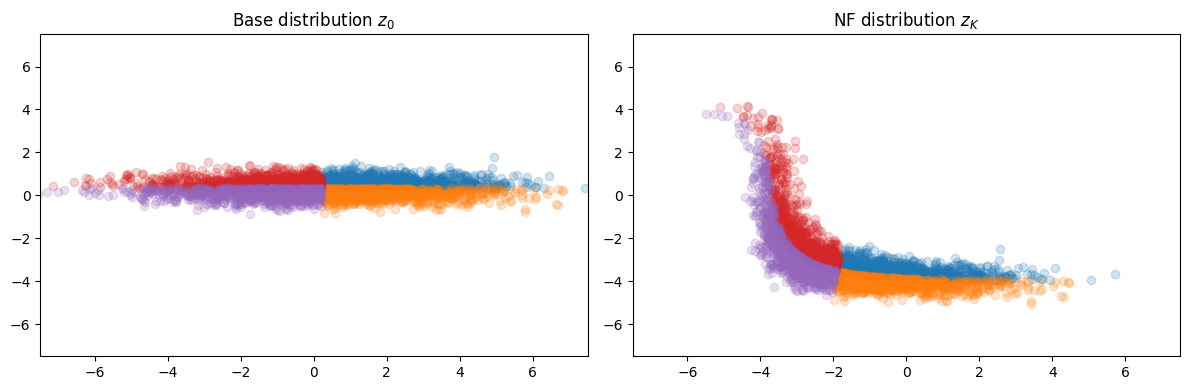

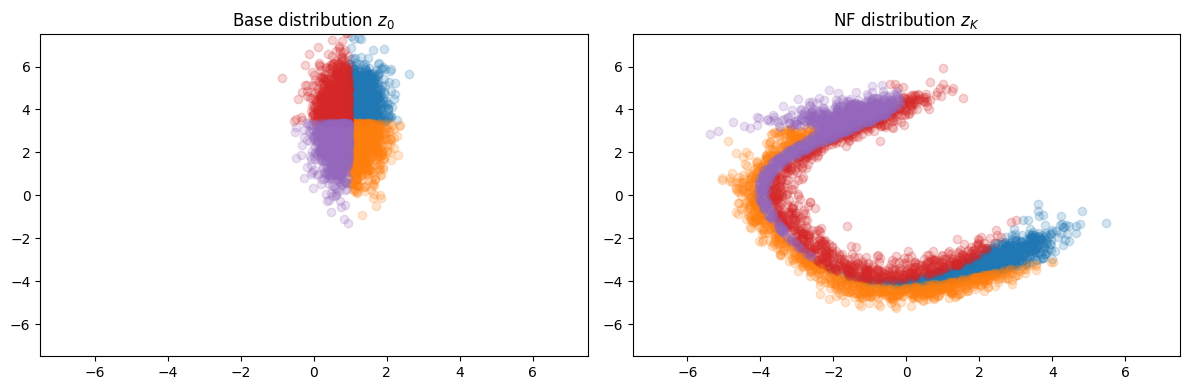

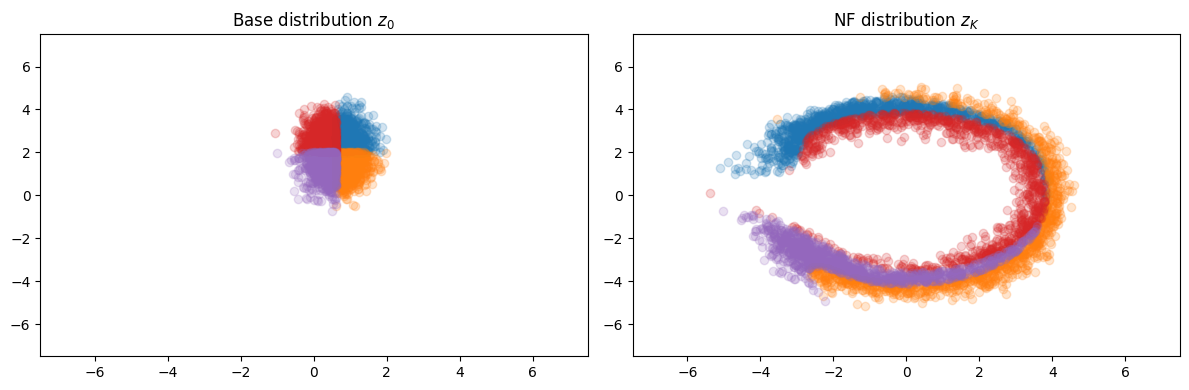

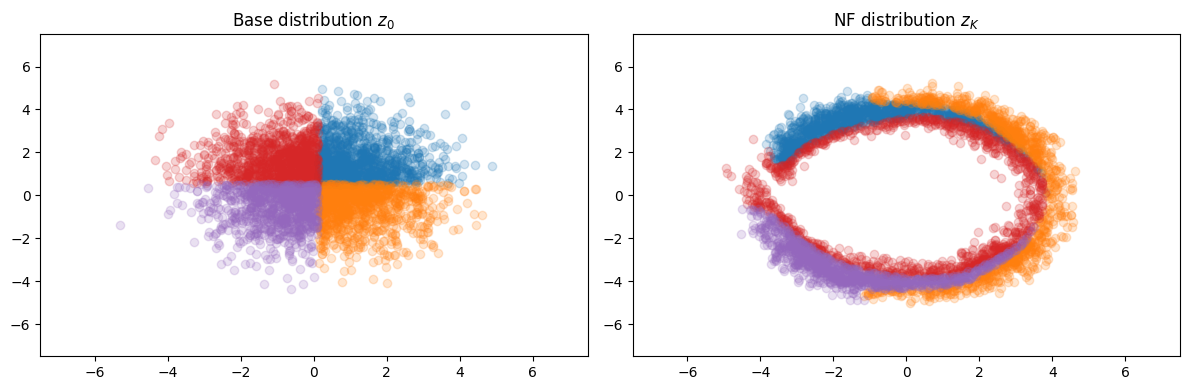

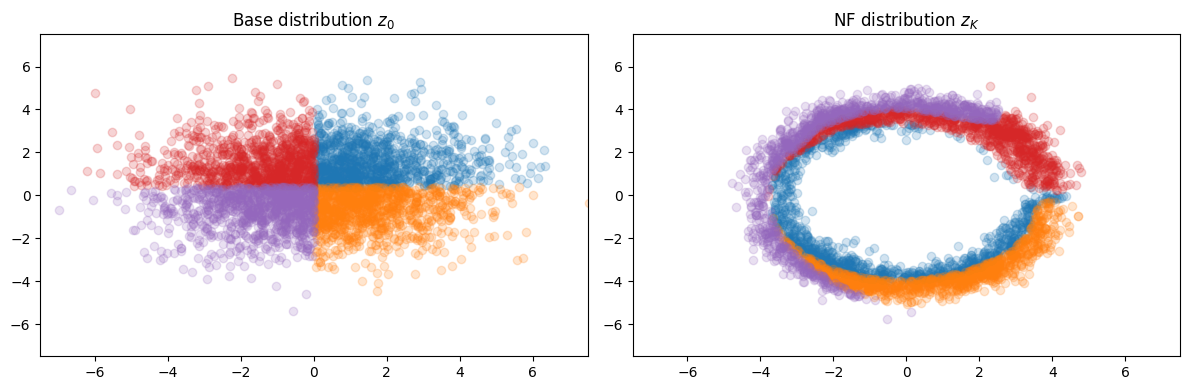

In [10]:
shape  = (6000, 2)                        # use n=6000 draws z0 from base measure
n_eps  = 5000                             # run SGD for 5000 iterations

for n_flows in [1, 4, 8, 16, 32]:
    flow = Flow(dim=2, n_flows=n_flows)       # define flow: 2d-dist and n_flows transformations

    train_flow(flow, shape, epochs=n_eps)     # train flow 

    z0, zk, ldj, mu, log_var = flow((4000, 2)) # draw 4000 samples for plotting 
    show_samples(z0.data, zk.data, mu, f"N-flows: {n_flows}")